In [1]:
# 
# import pandas as pd

# # Load the raw Kaggle file
# df = pd.read_csv(r"C:\Users\ericl\OneDrive\Desktop\GitHub\Lending Club Loan Dataset 2007_2011\loan.csv")  # adjust to your actual raw path

# # Fix int_rate: strip '%' and convert to float
# df['int_rate'] = df['int_rate'].str.rstrip('%').astype(float)

# # Fix issue_d: convert text to real datetime
# df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%y')

# # Save the cleaned version
# df.to_csv(r"C:\Users\ericl\OneDrive\Desktop\GitHub\Lending Club Loan Dataset 2007_2011\loan_cleaned.csv", index=False)


C:\Users\ericl\AppData\Local\Temp\ipykernel_29812\1913039524.py:5: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\ericl\OneDrive\Desktop\GitHub\Lending Club Loan Dataset 2007_2011\loan_cleaned.csv")


Population mean: 11219.44
Population median: 10000.00
Population std: 7456.67


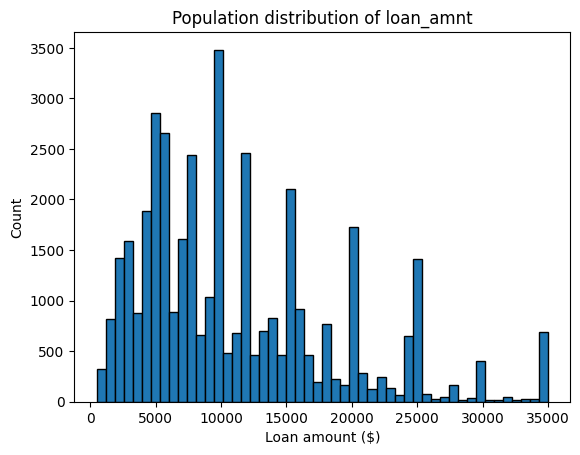

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r"C:\Users\ericl\OneDrive\Desktop\GitHub\Lending Club Loan Dataset 2007_2011\loan_cleaned.csv")
population = df['loan_amnt'].dropna()

print(f"Population mean: {population.mean():.2f}")
print(f"Population median: {population.median():.2f}")
print(f"Population std: {population.std():.2f}")

plt.hist(population, bins=50, edgecolor='black')
plt.title("Population distribution of loan_amnt")
plt.xlabel("Loan amount ($)")
plt.ylabel("Count")
plt.show()

In [3]:
# Draw the sample 5 times, see the means wobble
for i in range(5):
    s = population.sample(n=30, random_state=i)
    print(f"Sample {i}: mean = {s.mean():.2f}")

Sample 0: mean = 12855.00
Sample 1: mean = 11235.00
Sample 2: mean = 11127.50
Sample 3: mean = 13145.00
Sample 4: mean = 11827.50


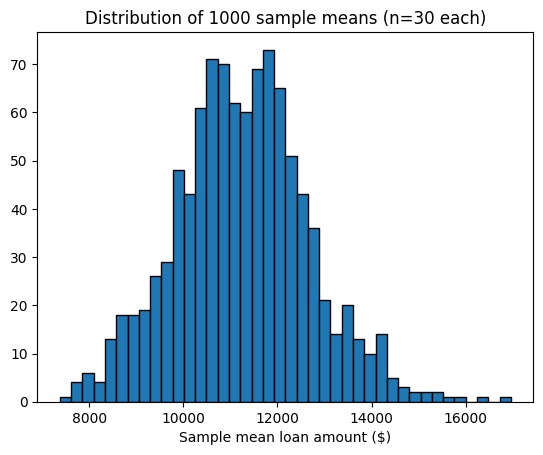

Mean of sample means: 11253.37
Std of sample means:  1414.66


In [4]:
# Simulate drawing 1000 samples of size 30, record each sample's mean
sample_means = []
for _ in range(1000):
    s = population.sample(n=30)
    sample_means.append(s.mean())

sample_means = np.array(sample_means)

plt.hist(sample_means, bins=40, edgecolor='black')
plt.title("Distribution of 1000 sample means (n=30 each)")
plt.xlabel("Sample mean loan amount ($)")
plt.show()

print(f"Mean of sample means: {sample_means.mean():.2f}")
print(f"Std of sample means:  {sample_means.std():.2f}")

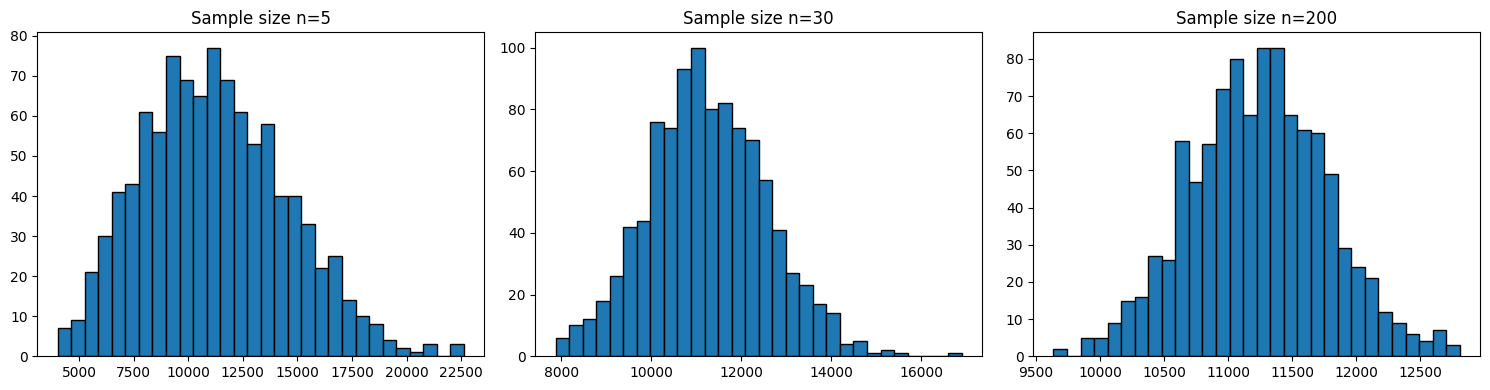

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, [5, 30, 200]):
    means = [population.sample(n=n).mean() for _ in range(1000)]
    ax.hist(means, bins=30, edgecolor='black')
    ax.set_title(f"Sample size n={n}")

plt.tight_layout()
plt.show()

In [6]:
n = 30
se_theoretical = population.std() / np.sqrt(n)
se_simulated = sample_means.std()  # from Part 3

print(f"Theoretical SE (formula): {se_theoretical:.2f}")
print(f"Simulated std of sample means: {se_simulated:.2f}")

Theoretical SE (formula): 1361.40
Simulated std of sample means: 1414.66


In [7]:
population_int = df['int_rate'].dropna()

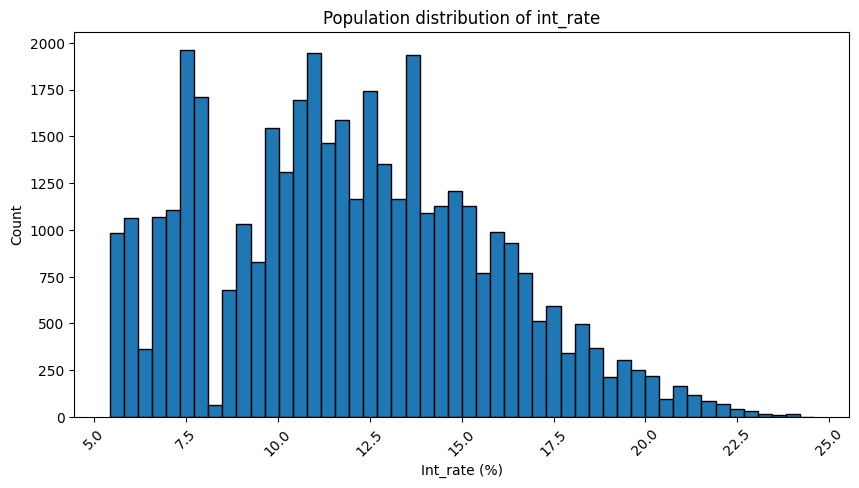

In [8]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 5))
plt.hist(population_int, bins=50, edgecolor='black')
plt.title("Population distribution of int_rate")
plt.xlabel("Int_rate (%)")
plt.ylabel("Count")

ax = plt.gca()  # "get current axis" — grabs the axis object so we can control it directly
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.xticks(rotation=45)

plt.show()

(array([ 2.,  0.,  2.,  4.,  2.,  9., 10., 10., 17., 19., 22., 18., 21.,
        29., 28., 33., 38., 40., 39., 42., 42., 59., 55., 48., 42., 44.,
        44., 38., 44., 34., 29., 24., 21., 19.,  9., 13.,  8.,  8.,  8.,
         9.,  7.,  0.,  4.,  2.,  0.,  2.,  0.,  1.,  0.,  1.]),
 array([10.26066667, 10.33956   , 10.41845333, 10.49734667, 10.57624   ,
        10.65513333, 10.73402667, 10.81292   , 10.89181333, 10.97070667,
        11.0496    , 11.12849333, 11.20738667, 11.28628   , 11.36517333,
        11.44406667, 11.52296   , 11.60185333, 11.68074667, 11.75964   ,
        11.83853333, 11.91742667, 11.99632   , 12.07521333, 12.15410667,
        12.233     , 12.31189333, 12.39078667, 12.46968   , 12.54857333,
        12.62746667, 12.70636   , 12.78525333, 12.86414667, 12.94304   ,
        13.02193333, 13.10082667, 13.17972   , 13.25861333, 13.33750667,
        13.4164    , 13.49529333, 13.57418667, 13.65308   , 13.73197333,
        13.81086667, 13.88976   , 13.96865333, 14.04754667,

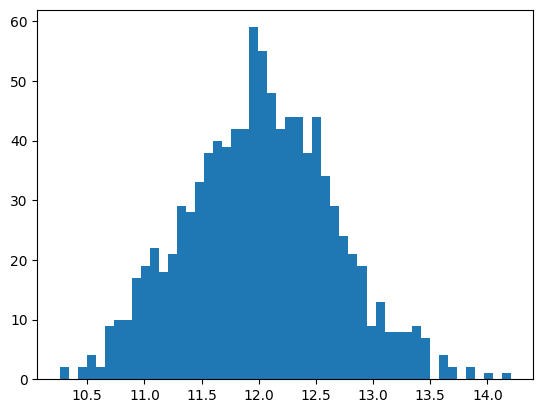

In [12]:
m = 30
reps = 1000
means_2 = []

for _ in range(reps):
    temp = population_int.sample(n=n).mean()
    means_2.append(temp)

plt.hist(means_2, bins = 50)

In [20]:
se_simulated = np.std(means_2)
se_theoretical = population_int.std() / np.sqrt(30)
print(se_simulated)
print(se_theoretical)

0.644789421531557
0.6800569711936847


In [17]:
print(np.mean(means_2))
print(population_int.mean())

12.015641
12.021176574262908
